<a href="https://colab.research.google.com/github/xuanbin159/BK_pot_DV/blob/main/3_whitespace_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3. 시장 공백 탐색 (Market Whitespace Detection)

본 노트북은 KDE(Kernel Density Estimation) 기반으로 2차원 임베딩 공간에서 시장 공백(vacuum point)을 탐색하고 시각화합니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.ticker as ticker
import torch

In [2]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3.1 데이터 로드

In [3]:
p_name = 'TF'
# save_dir = f'/content/drive/MyDrive/beam_width_results_{p_name}'

# 인코딩된 임베딩 로드
encoded_df = pd.read_csv('/content/drive/MyDrive/embeddings_last.csv')
encoded_embeddings = torch.tensor(encoded_df.values, dtype=torch.float64)
print(f"인코딩된 임베딩 shape: {encoded_embeddings.shape}")

인코딩된 임베딩 shape: torch.Size([642, 1536])


## 3.2 Vacuum Point 탐색 함수 정의

In [4]:
def visualize_and_find_vacuum_points(encoded_embeddings, interval_num, grid_size=0.00015, win=1):
    x = encoded_embeddings[:, 0].numpy()
    y = encoded_embeddings[:, 1].numpy()
    data = np.vstack([x, y]).T

    # KDE 대역폭 계산 (Silverman's rule)
    kde_bandwidth = 1.06 * (len(data))**(-1/(2 + 4))

    # 그리드 생성
    x_min, x_max = data[:, 0].min() - grid_size, data[:, 0].max() + grid_size
    y_min, y_max = data[:, 1].min() - grid_size, data[:, 1].max() + grid_size
    x_centers = np.arange(x_min + grid_size/2, x_max, grid_size)
    y_centers = np.arange(y_min + grid_size/2, y_max, grid_size)
    x_grid, y_grid = np.meshgrid(x_centers, y_centers)

    # KDE 계산
    kde = gaussian_kde(data.T, bw_method=kde_bandwidth)
    grid_density = kde(np.vstack([x_grid.ravel(), y_grid.ravel()]))

    # 밀도 레벨 계산
    density_sorted = np.sort(grid_density.ravel())
    percentiles = [0, 70, 85, 95, 100]
    levels = [np.percentile(density_sorted, p) for p in percentiles]
    levels = np.unique(levels)

    if interval_num < 1 or interval_num > len(levels)-1:
        raise ValueError(f"올바른 구간 번호를 입력하세요 (1 ~ {len(levels)-1}).")

    min_percent, max_percent = levels[interval_num - 1], levels[interval_num]
    print(f"선택한 밀도 구간: {min_percent:.6f} ~ {max_percent:.6f}")

    # 밀도 구간 내에서 데이터 포인트가 없는 곳 찾기
    vacuum_points = []
    for i, density in enumerate(grid_density):
        if min_percent <= density < max_percent:
            center_x, center_y = x_grid.ravel()[i], y_grid.ravel()[i]
            in_x_range = (data[:, 0] > (center_x - (grid_size*win)/2)) & (data[:, 0] <= (center_x + (grid_size*win)/2))
            in_y_range = (data[:, 1] > (center_y - (grid_size*win)/2)) & (data[:, 1] <= (center_y + (grid_size*win)/2))

            if not np.any(in_x_range & in_y_range):
                overlap = False
                for vp_x, vp_y in vacuum_points:
                    if ((vp_x > (center_x - (grid_size * win) / 2)) and (vp_x <= (center_x + (grid_size * win) / 2)) and
                        (vp_y > (center_y - (grid_size * win) / 2)) and (vp_y <= (center_y + (grid_size * win) / 2))):
                        overlap = True
                        break
                if not overlap:
                    vacuum_points.append((center_x, center_y))

    print(f"선택한 구간 내 식별된 Vacuum 수: {len(vacuum_points)}")

    # 시각화
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.imshow(np.rot90(grid_density.reshape(x_grid.shape)), cmap='coolwarm', extent=(x_min, x_max, y_min, y_max))
    ax.plot(data[:, 0], data[:, 1], 'w.', markersize=1.8)

    vacuum_x, vacuum_y = np.array(vacuum_points).T
    ax.plot(vacuum_x, vacuum_y, 'ko', markersize=2.5)

    ax.set_xticks(np.arange(x_min, x_max, grid_size), minor=True)
    ax.set_yticks(np.arange(y_min, y_max, grid_size), minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.6)

    ax.set_title(f'2D Embeddings Visualization ({grid_size} scale, Interval: {interval_num})')
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')

    contour_set = plt.contourf(x_grid, y_grid, grid_density.reshape(x_grid.shape), cmap='coolwarm', levels=levels)
    cbar = plt.colorbar(contour_set)
    cbar.set_ticks(levels)
    cbar.set_ticklabels([f"{p}%" for p in percentiles])
    cbar.ax.set_ylabel('Density Percentile')

    plt.show()
    return vacuum_points

## 3.3 단일 구간 Vacuum Point 탐색

선택한 밀도 구간: 1222.619943 ~ 1664.021417
선택한 구간 내 식별된 Vacuum 수: 465


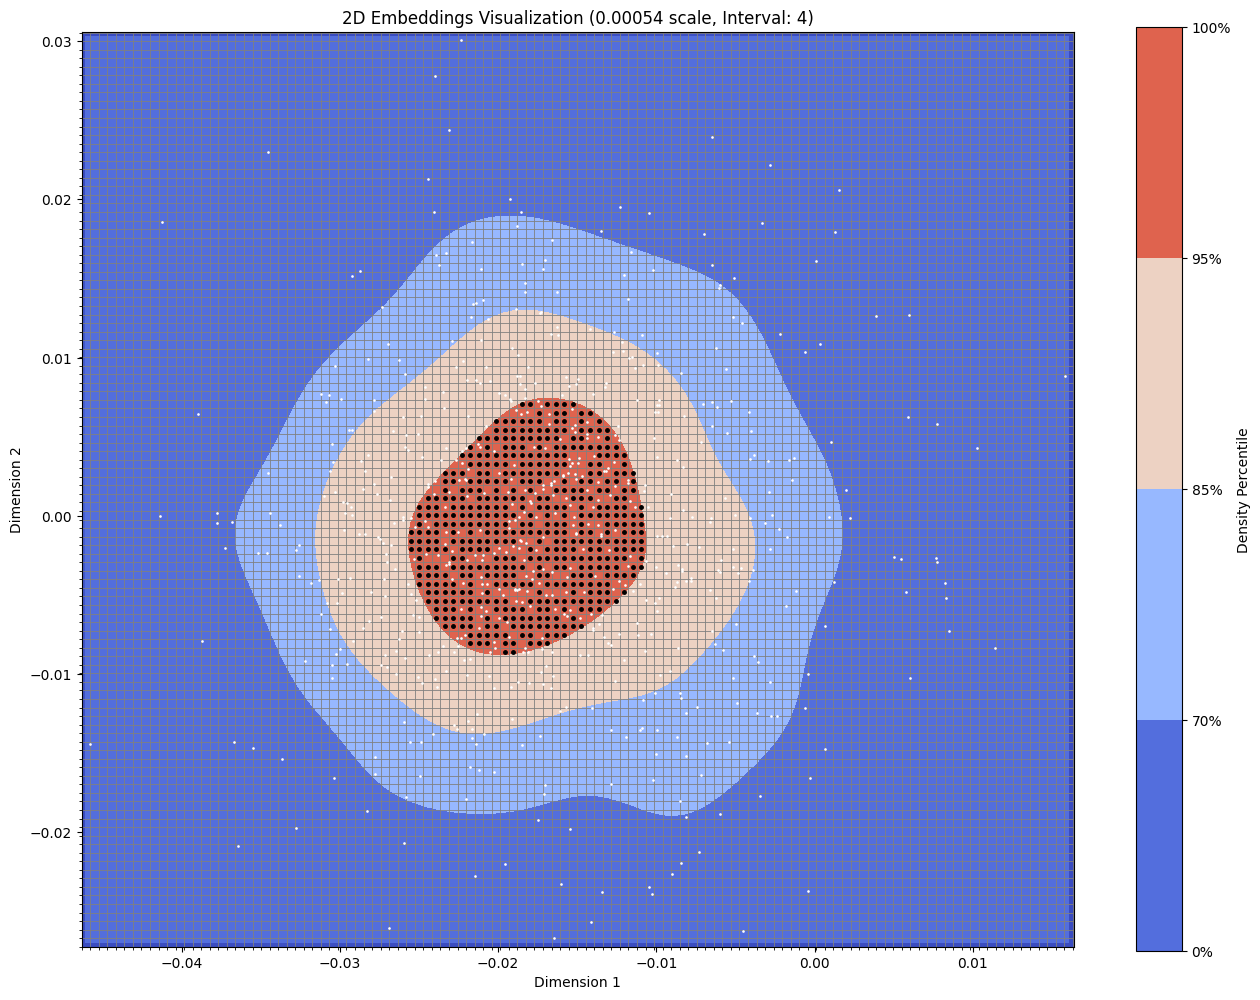

In [5]:
vacuum_points = visualize_and_find_vacuum_points(
    encoded_embeddings, interval_num=4, grid_size=0.00054)

## 3.4 다중 구간 Vacuum Point 탐색

선택한 밀도 구간: 1222.619943 ~ 1664.021417
선택한 구간 내 식별된 Vacuum 수: 465


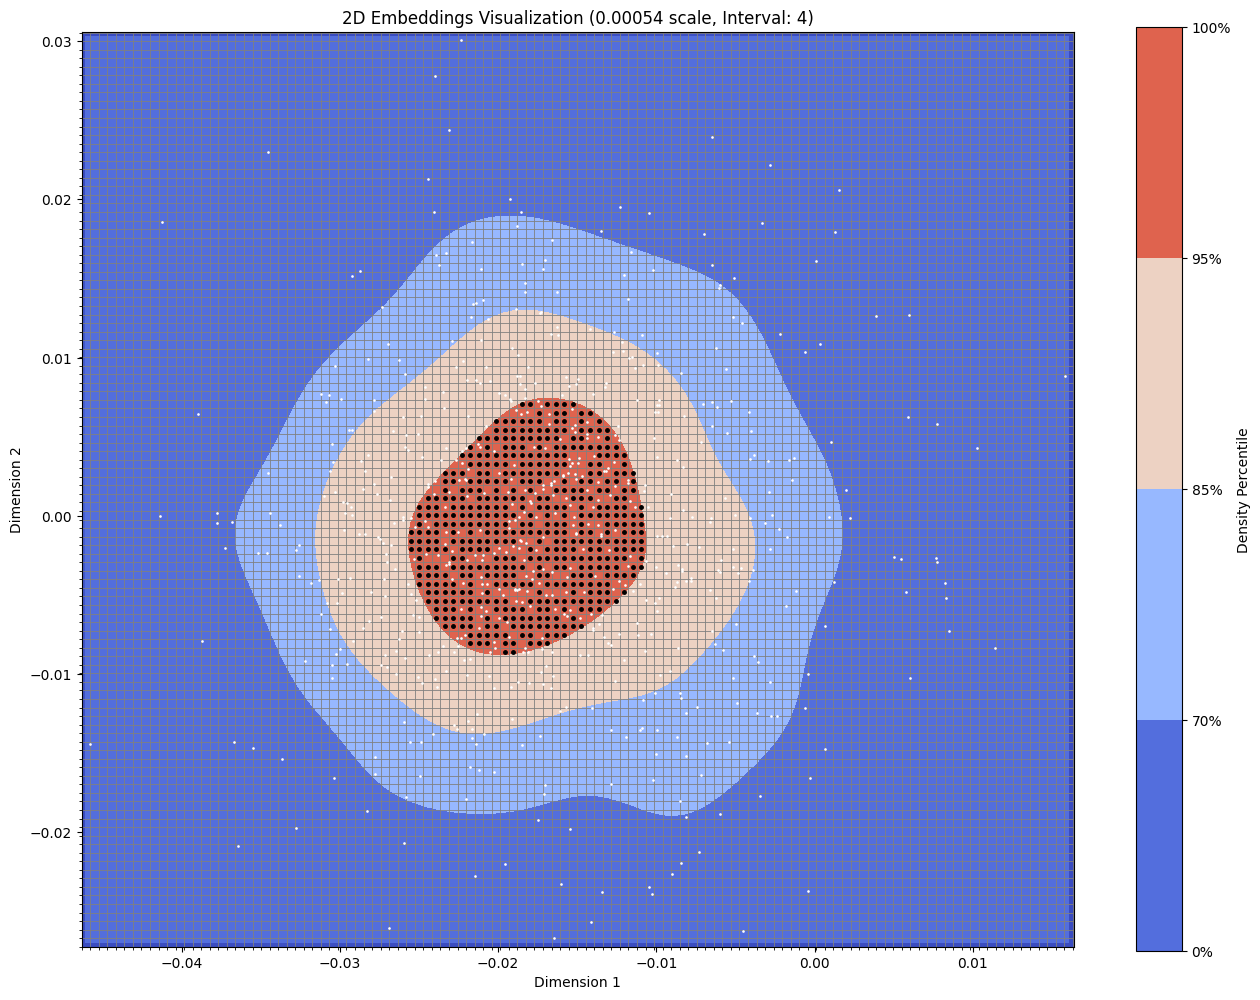

선택한 밀도 구간: 665.357274 ~ 1222.619943
선택한 구간 내 식별된 Vacuum 수: 1032


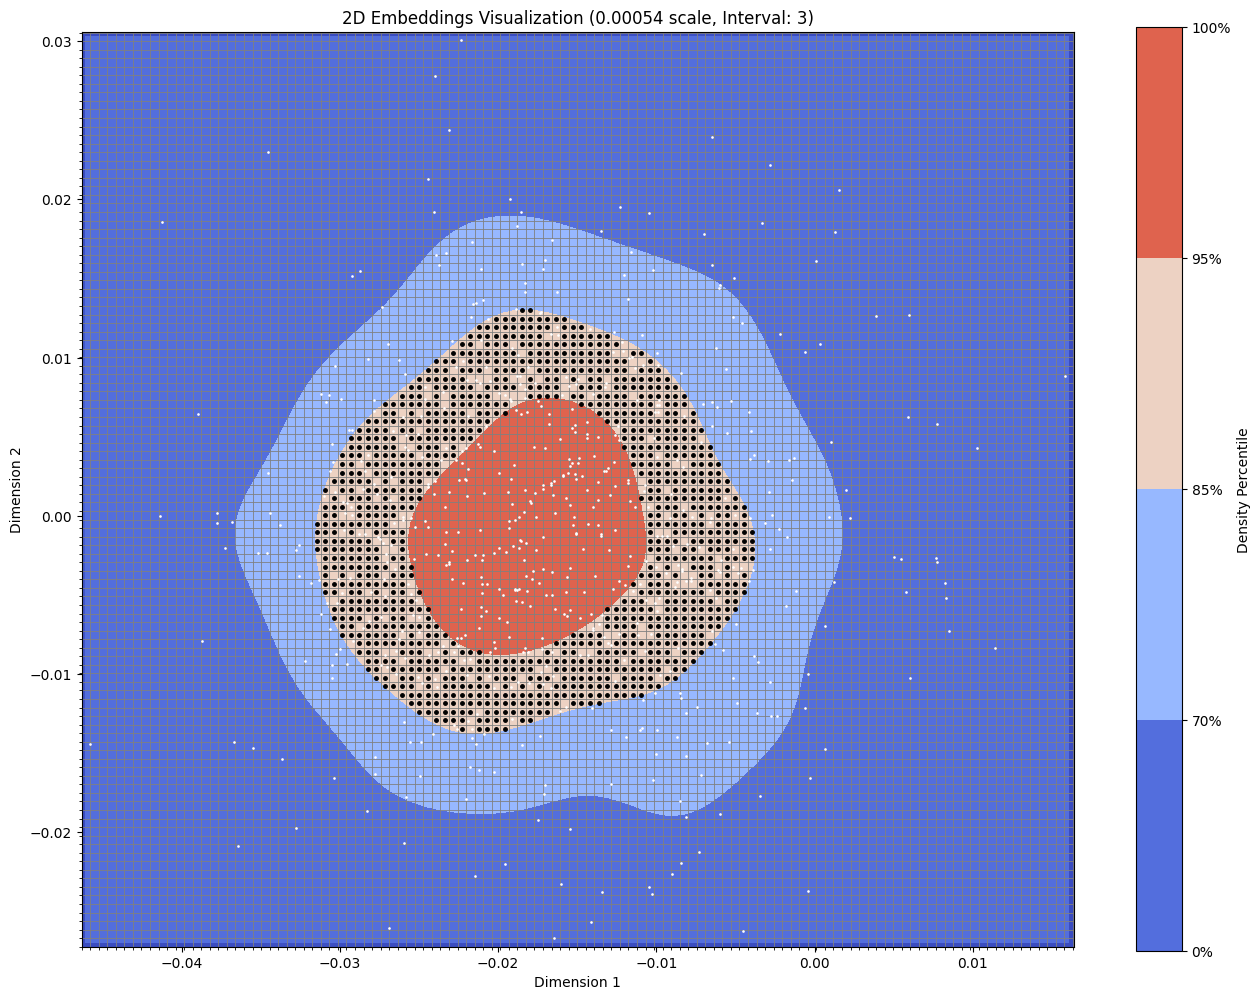

선택한 밀도 구간: 260.021654 ~ 665.357274
선택한 구간 내 식별된 Vacuum 수: 1723


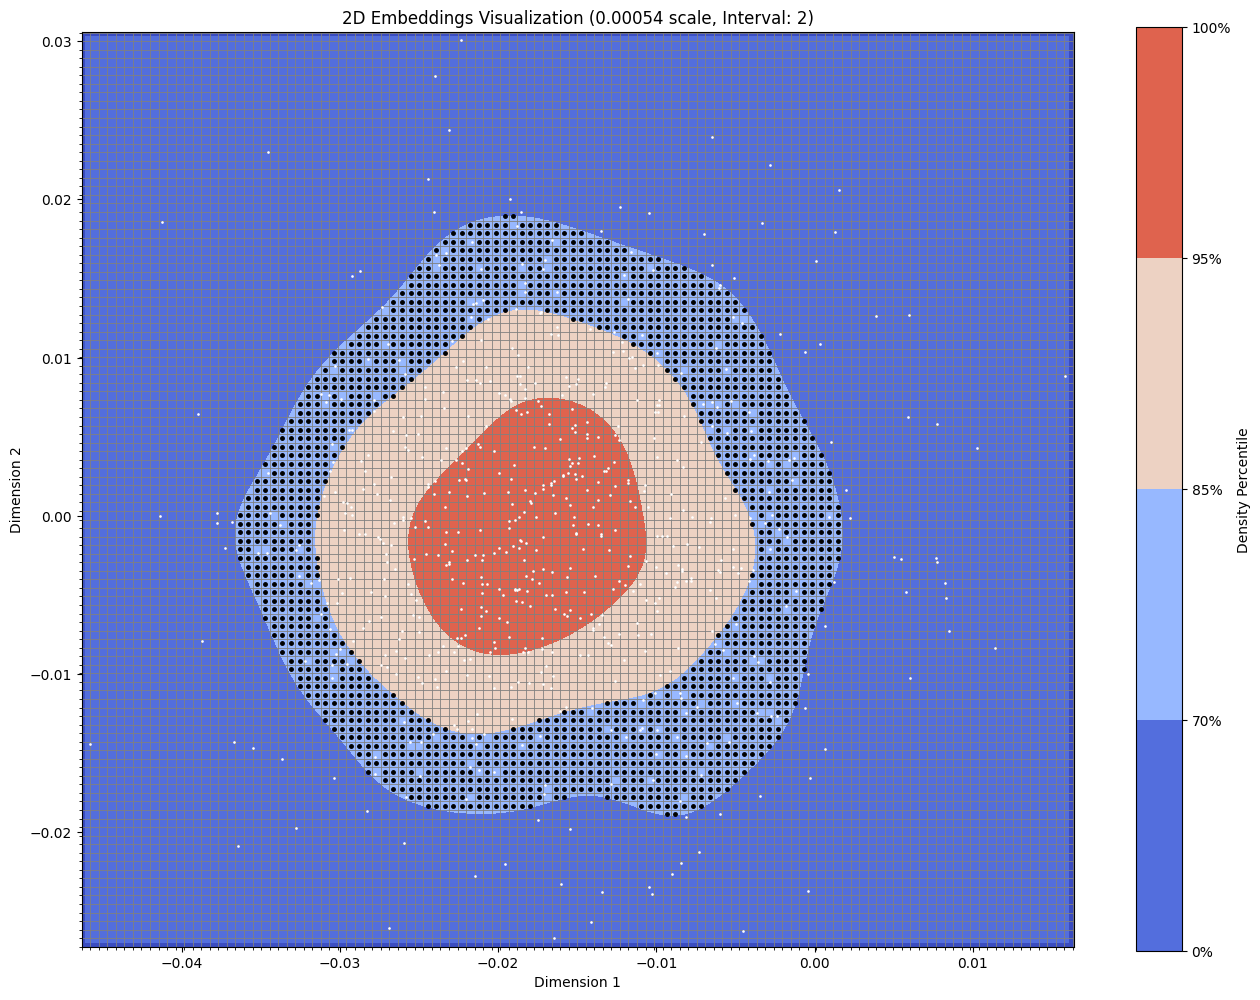

Interval 2: Original count = 1723, Sampled count = 1723
Interval 3: Original count = 1032, Sampled count = 1032
Interval 4: Original count = 465, Sampled count = 465


In [6]:
import random

def record_results_count(interval_num, original_count, sampled_count):
    return {
        'interval_num': interval_num,
        'original_count': original_count,
        'sampled_count': sampled_count
    }

revers = []
results_counts = []
original_grid_size = 0.00054

for interval_num in range(4, 1, -1):
    grid_size = original_grid_size if interval_num >= 1 else original_grid_size * 2

    vacuum_points = visualize_and_find_vacuum_points(
        encoded_embeddings,
        grid_size=grid_size,
        interval_num=interval_num,
        win=1
    )

    original_count = len(vacuum_points)
    sampled_count = len(vacuum_points)

    revers.append(vacuum_points)
    results_counts.append(record_results_count(interval_num, original_count, sampled_count))

revers.reverse()
results_counts.reverse()

for count_info in results_counts:
    print(f"Interval {count_info['interval_num']}: Original count = {count_info['original_count']}, Sampled count = {count_info['sampled_count']}")